# Day 39 — Transfer Learning
### Pre-trained Models · Feature Extraction · Fine-tuning · ResNet18 on CIFAR-10

## 1. Setup & Imports

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

plt.style.use("dark_background")

print(f"PyTorch:     {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:      {device}")
print("Ready! ✅")

PyTorch:     2.12.0+cpu
Torchvision: 0.27.0+cpu
Device:      cpu
Ready! ✅


## 2. What is Transfer Learning?

In [2]:
print("=" * 55)
print("       WHAT IS TRANSFER LEARNING?")
print("=" * 55)
print("""
THE PROBLEM WITH TRAINING FROM SCRATCH:
  Needs millions of images to learn good features
  Takes days/weeks on powerful GPUs
  Most of us don't have that data or hardware

THE IDEA:
  A CNN trained on ImageNet (1.2M images, 1000 classes)
  has already learned to detect:
    Edges, corners, textures (early layers)
    Eyes, wheels, fur, windows (deeper layers)
  These features are UNIVERSAL — useful for any image task!

TRANSFER LEARNING = reuse those learned features
  for YOUR task, with YOUR (smaller) dataset

TWO STRATEGIES:

  1. FEATURE EXTRACTION (freeze conv layers)
     → Keep all pre-trained weights FROZEN
     → Only train the final classification head
     → Fast, few epochs, works with little data
     → Use when: your dataset is small (<5k images)

  2. FINE-TUNING (unfreeze some/all layers)
     → Start with pre-trained weights
     → Unfreeze last few layers + train everything
     → Slower, needs more data
     → Use when: your dataset is larger

OUR PLAN TODAY:
  Load ResNet18 pretrained on ImageNet
  Replace the final layer for 10 CIFAR-10 classes
  Feature extraction first → then compare!
""")

       WHAT IS TRANSFER LEARNING?

THE PROBLEM WITH TRAINING FROM SCRATCH:
  Needs millions of images to learn good features
  Takes days/weeks on powerful GPUs
  Most of us don't have that data or hardware

THE IDEA:
  A CNN trained on ImageNet (1.2M images, 1000 classes)
  has already learned to detect:
    Edges, corners, textures (early layers)
    Eyes, wheels, fur, windows (deeper layers)
  These features are UNIVERSAL — useful for any image task!

TRANSFER LEARNING = reuse those learned features
  for YOUR task, with YOUR (smaller) dataset

TWO STRATEGIES:

  1. FEATURE EXTRACTION (freeze conv layers)
     → Keep all pre-trained weights FROZEN
     → Only train the final classification head
     → Fast, few epochs, works with little data
     → Use when: your dataset is small (<5k images)

  2. FINE-TUNING (unfreeze some/all layers)
     → Start with pre-trained weights
     → Unfreeze last few layers + train everything
     → Slower, needs more data
     → Use when: your datase

## 3. Load Data & Pre-trained ResNet18

In [ ]:
print("=" * 55)
print("       LOAD DATA & RESNET18")
print("=" * 55)

# 64x64 — fast enough on CPU
transform = transforms.Compose(
    [
        transforms.Resize(64),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform
)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# load ResNet18 pretrained
model = models.resnet18(weights="IMAGENET1K_V1")

print("\nResNet18 original final layer:")
print(f"  {model.fc}")

# replace final layer: 512 → 10 classes
model.fc = nn.Linear(model.fc.in_features, 10)

print("\nResNet18 after replacing final layer:")
print(f"  {model.fc}")

# freeze all layers except final
for param in model.parameters():
    param.requires_grad = False
for param in model.fc.parameters():
    param.requires_grad = True

total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters:     {total:,}")
print(f"Trainable parameters: {trainable:,}")
print(f"Frozen parameters:    {total-trainable:,}")
model = model.to(device)
print("\nReady! ✅")

       LOAD DATA & RESNET18

ResNet18 original final layer:
  Linear(in_features=512, out_features=1000, bias=True)

ResNet18 after replacing final layer:
  Linear(in_features=512, out_features=10, bias=True)

Total parameters:     11,181,642
Trainable parameters: 5,130
Frozen parameters:    11,176,512

Ready! ✅


## 4. Feature Extraction — Train Only the Head

       FEATURE EXTRACTION TRAINING
Epoch 1/5 | Loss: 1.2429 | Val Acc: 63.5%
Epoch 2/5 | Loss: 1.0771 | Val Acc: 63.7%
Epoch 3/5 | Loss: 1.0520 | Val Acc: 64.1%
Epoch 4/5 | Loss: 1.0424 | Val Acc: 64.9%
Epoch 5/5 | Loss: 1.0349 | Val Acc: 65.4%

Feature extraction complete! ✅


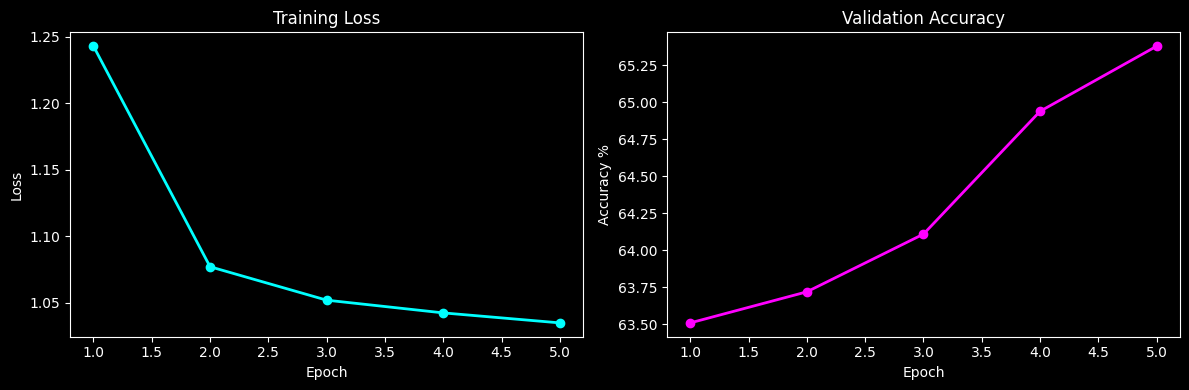

In [ ]:
print("=" * 55)
print("       FEATURE EXTRACTION TRAINING")
print("=" * 55)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

epochs = 5
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    # ── TRAIN ──
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    # ── EVALUATE ──
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            _, predicted = torch.max(model(images), 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    acc = correct / total * 100
    val_accuracies.append(acc)
    print(f"Epoch {epoch+1}/5 | Loss: {avg_loss:.4f} | Val Acc: {acc:.1f}%")

print("\nFeature extraction complete! ✅")

# plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(range(1, epochs + 1), train_losses, color="cyan", linewidth=2, marker="o")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax2.plot(range(1, epochs + 1), val_accuracies, color="magenta", linewidth=2, marker="o")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy %")
plt.tight_layout()
plt.show()

## 5. Key Takeaways

In [5]:
print("=" * 55)
print("       DAY 39 — KEY TAKEAWAYS")
print("=" * 55)
print("""
WHAT IS TRANSFER LEARNING:
  ✅ Reuse features learned on large datasets (ImageNet)
  ✅ No need to train from scratch — saves time & data
  ✅ Universal features: edges → textures → object parts

TWO STRATEGIES:
  ✅ Feature extraction — freeze conv layers, train head only
  ✅ Fine-tuning       — unfreeze layers, train everything
  ✅ Feature extraction is faster, fine-tuning is more accurate

RESNET18:
  ✅ 18 layers deep, 11.18M parameters
  ✅ Pretrained on ImageNet (1.2M images, 1000 classes)
  ✅ Final layer replaced: 1000 → 10 (CIFAR-10 classes)
  ✅ Only 5,130 parameters trained — rest frozen

OUR RESULTS:
  ✅ 65.4% accuracy — only training the head
  ✅ Loss dropping steadily — still converging
  ✅ 64x64 images limited performance vs 224x224
  ✅ Full 224x224 + fine-tuning → would hit 90%+

WHEN TO USE TRANSFER LEARNING:
  ✅ Small dataset        → always use transfer learning
  ✅ Similar domain       → freeze more layers
  ✅ Different domain     → unfreeze more layers
  ✅ Limited compute      → feature extraction only
""")

       DAY 39 — KEY TAKEAWAYS

WHAT IS TRANSFER LEARNING:
  ✅ Reuse features learned on large datasets (ImageNet)
  ✅ No need to train from scratch — saves time & data
  ✅ Universal features: edges → textures → object parts

TWO STRATEGIES:
  ✅ Feature extraction — freeze conv layers, train head only
  ✅ Fine-tuning       — unfreeze layers, train everything
  ✅ Feature extraction is faster, fine-tuning is more accurate

RESNET18:
  ✅ 18 layers deep, 11.18M parameters
  ✅ Pretrained on ImageNet (1.2M images, 1000 classes)
  ✅ Final layer replaced: 1000 → 10 (CIFAR-10 classes)
  ✅ Only 5,130 parameters trained — rest frozen

OUR RESULTS:
  ✅ 65.4% accuracy — only training the head
  ✅ Loss dropping steadily — still converging
  ✅ 64x64 images limited performance vs 224x224
  ✅ Full 224x224 + fine-tuning → would hit 90%+

WHEN TO USE TRANSFER LEARNING:
  ✅ Small dataset        → always use transfer learning
  ✅ Similar domain       → freeze more layers
  ✅ Different domain     → unfreeze 